In [13]:
import flux_calc_parallel
import flux_variables
import thermalsyn_v2 as MQ24
import Constants as C
from astropy.cosmology import Planck18

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

import pandas as pd

from scipy.optimize import least_squares
from scipy.optimize import curve_fit

In [14]:
# These below params should be altered to see the effects!
s = 1e5 # Effective range of magnetic field values B1/B0
a = 3.0 # Index for magnetic field probability distribution
delta = 1.0 # Index for explicit relation between post-shock number density and magnetic field strength

R = 1e16 # Undocumented... forward shock wave radius

T = 50 # Time (days) of observation in observer's frame
n0 = 1e3 # Nominal value for upstream number density
eps_e = 0.000001 # Fraction of local fluid energy in power-law electrons
eps_B = 0.1 # Fraction of local fluid energy in magnetic field
eps_T = 0.4 # Fraction of local fluid energy in thermal electrons
p = 3.0 # Power-law electron distribution index

BG = 0.01 # Shock proper velocity at R=R0 (the radius at which the maximum perpendicular 
          # extent of the shock is reached; see Figure 1 in FM25)
k = 0 # Power-law index for stratified density (Eq. 12 in FM25)
alpha = 0 # Power-law index for deceleration (Eq. 11 in FM25)

# These will flip flop, overlay both when altering the above
therm_el = True # If True---calculates thermal electron synchrotron flux
pl_el = False # If True---calculates power-law electron synchrotron flux

# These stay constant or are already known for a source
mu_u = 0.62 # Mean molecular weight; nominal value 0.62
mu_e = 1.18 # Mean molecular weight per electron; nominal value 1.18
d_L = 10**28 # Luminosity distance (cm)
nu_res = 500 # Frequency array length
z = 0 # Source redshift

#nu_low, nu_high = 1e-2,1e19
nu_low, nu_high = 5e9,1e12

base_params = dict(
a=a, R=R, BG=BG, n0=n0, eps_B=eps_B,
s=s, delta=delta, eps_e=eps_e, eps_T=eps_T, 
p=p, k=k, alpha=alpha, mu_u=mu_u,
mu_e=mu_e, T=T, z=z, d_L=d_L,
nu_res=nu_res, nu_low=nu_low, nu_high=nu_high,
)

b = {
    "a":     (0.5, 4.0),
    "R":     (14, 18), # log(cm)
    "BG":    (0.01, 2.1),
    "n0":    (-2, 6), # log(cm^-3)
    "eps_B": (-5, -0.3) # log()
}

# We set mu_u and mu_e to their defaults. 
# Event dependent info: z, d_L, T

# Things we could change but prob won't:
# eps_e, eps_T, k, alpha, s, delta

# Things we should def change (in accordance to Ross' advice):
# R, BG, n0, a, eps_B

In [15]:
def AT2024wpp(epoch):

    color = "#ffa600"
    name = "24wpp"
    filename = "../../data/whippet_radio.txt"
    data = pd.read_csv(filename, sep="\t", skiprows=1, names=[
           "FBOTName", "dt_days", "nu_GHz", "flux_mJy", "ferr_mJy", "rms_mJy",
           "det", "reference", "obs", "timestart", "timestop", "tmid"])
    Days = data['dt_days'].values # days
    Freq = data['nu_GHz'].values * 1e9 # Hz
    Flux = data['flux_mJy'].values * 1e-3 # Jy 
    eFlux = data['ferr_mJy'].values * 1e-3 # Jy

    epochGroups = [
        #[12.02],
        [28.91,32.9,36.653,33.684,34.714],
        [43.88,43.611,43.628,43.670],
        [70.78,71.596,71.614,71.702],
        [110.70, 113.445, 128.65],
        [191.5],
        #[298.25]
    ]

    epochIndex = epoch - 1
    group = np.array(epochGroups[epochIndex])
    tMask = np.any(np.isclose(Days[:, None], group[None, :], rtol=0, atol=1e-3), axis=1)
    freq = Freq[tMask]
    flux = Flux[tMask]
    fluxErr = eFlux[tMask]
    
    # Known info
    T = np.mean(Days[tMask]) # Time (days) of observation in observer's frame
    z = 0.0868 # Source redshift
    d_L = Planck18.luminosity_distance(z).cgs.value # Luminosity distance (cm)

    source_params = {
        **base_params,
        "T": T,
        "z": z,
        "d_L": d_L
    }

    return source_params, d_L, freq, flux, fluxErr

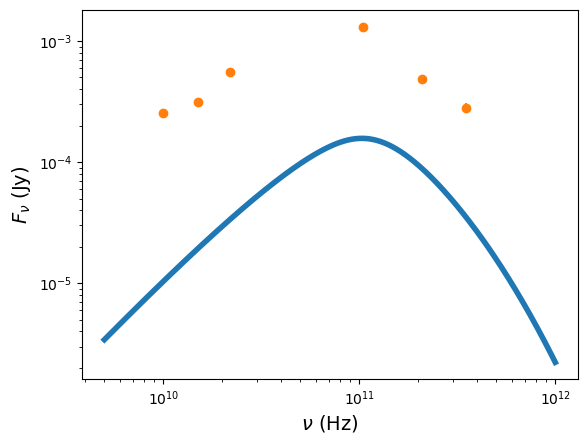

In [16]:
# This was my attempt at fitting an epoch's SED myself... harder than it looks

def compute_Lnu_R(params, therm_el, pl_el):
    nu = np.logspace(np.log10(params["nu_low"]), np.log10(params["nu_high"]), params["nu_res"])
    Lnu = flux_variables.LOS_IHG_Fitted_R(
        nu,
        params["s"], params["a"], params["delta"], params["R"],
        params["T"], params["n0"], params["eps_e"], params["eps_B"], params["eps_T"], params["p"],
        params["mu_u"], params["mu_e"],
        params["BG"], params["k"],
        params["d_L"], params["z"],
        therm_el=therm_el, pl_el=pl_el
    )
    return nu, Lnu

source_params, d_L, freq, flux, fluxErr = AT2024wpp(1)

aa = 1.15
RR = 1e16
BGBG = 0.7
n0n0 = 9e1
eps_Beps_B = 0.1
params = {
    **source_params,
    "a": aa,
    "R": RR,
    "BG": BGBG,
    "n0": n0n0,
    "eps_B": eps_Beps_B,
}

nu_model, Lnu_model = compute_Lnu_R(params, therm_el, pl_el)
Fnu_model = Lnu_model / (4*np.pi*d_L**2)/ C.Jy

plt.plot(nu_model, Fnu_model, lw=4,)
plt.errorbar(freq, flux, yerr=fluxErr, fmt='o')

plt.xscale('log'); plt.yscale('log')
plt.xlabel(r"$\nu$ (Hz)", fontsize=14); plt.ylabel(r"$F_\nu$ (Jy)", fontsize=14)
plt.show()

In [21]:
# Fitting epoch SEDs individually using least squares

def compute_Lnu_R(freq, params, therm_el, pl_el):
    Lnu = flux_variables.LOS_IHG_Fitted_R(
        freq,
        params["s"], params["a"], params["delta"], params["R"],
        params["T"], params["n0"], params["eps_e"], params["eps_B"], params["eps_T"], params["p"],
        params["mu_u"], params["mu_e"],
        params["BG"], params["k"],
        params["d_L"], params["z"],
        therm_el=therm_el, pl_el=pl_el
    )
    return Lnu

def model_Fnu_at_datafreq(theta, base_params, d_L, freq_hz, therm_el=True, pl_el=False):
    """
    theta = [a, log10R, BG, log10n0, log10eps_B]
    Returns model flux density (Jy) at the data frequencies.
    """
    a, log10R, BG, log10n0, log10epsB = theta

    params = {
        **base_params,
        "a": a,
        "R": 10.0**log10R,
        "BG": BG,
        "n0": 10.0**log10n0,
        "eps_B": 10.0**log10epsB,
    }

    Lnu = compute_Lnu_R(freq_hz, params, therm_el, pl_el)
    Fnu = Lnu / (4*np.pi*d_L**2) / C.Jy  # Jy
    return Fnu

def residuals(theta, base_params, d_L, freq_hz, flux_jy, eflux_jy, therm_el=True, pl_el=False):
    Fnu_model = model_Fnu_at_datafreq(theta, base_params, d_L, freq_hz, therm_el=therm_el, pl_el=pl_el)
    return (Fnu_model - flux_jy) / eflux_jy

def chi2(theta, base_params, d_L, freq_hz, flux_jy, eflux_jy, therm_el=True, pl_el=False):
    r = residuals(theta, base_params, d_L, freq_hz, flux_jy, eflux_jy, therm_el=therm_el, pl_el=pl_el)
    return float(np.sum(r**2))

# a, R, BG, n0, eps_B
lb = np.array([0.5, 14.0, 0.01, -2.0, -5.0]) # lower bounds
ub = np.array([4.0, 18.0, 2.10,  6.0, -0.3]) # upper bounds
bounds = (lb, ub)

# Starting sample!!!!!
theta0 = np.array([3.0,np.log10(1e16),0.01,np.log10(1e3),np.log10(0.1)])

def fit_and_plot_epoch_chi2(epoch, theta0, bounds, therm_el=True, pl_el=False):
    """Makes dictionary with fit results + arrays used for plotting."""

    # load epoch data
    source_params, d_L, freq, flux, fluxErr = AT2024wpp(epoch)

    # chi^2 minimization
    res = least_squares(residuals, x0=theta0, bounds=bounds, 
                        args=(source_params, d_L, freq, flux, fluxErr, therm_el, pl_el), 
                        method="trf") # This method is the default but might be worth changing it

    popt, pcov = curve_fit(
        f_model,              # returns model flux at freq
        xdata=freq,
        ydata=flux,
        p0=theta0,
        sigma=fluxErr,        # 1σ errors
        absolute_sigma=True,  # IMPORTANT if you want real parameter uncertainties
        bounds=bounds,        # supported
        method="trf",         # or "dogbox"
    )

    theta_hat = res.x # found solution
    chi2_min = float(np.sum(res.fun**2)) # found solutions chi^2
    
    theta_hat = popt
    model = f_model(freq, *popt)
    chi2_min = float(np.sum(((model - flux) / fluxErr)**2))

    ndof = len(freq) - len(theta_hat)
    if ndof > 0: red_chi2 = chi2_min / ndof
    else: red_chi2 = np.nan

    print(f"\nEpoch {epoch}")
    print("----------------")
    print("Best-fit theta = [a, log10R, BG, log10n0, log10eps_B]")
    print(theta_hat)
    print(f"chi2 = {chi2_min:.3g}, ndof = {ndof}, red chi2 = {red_chi2:.3g}")

    # build smooth curve
    nu_grid = np.logspace(np.log10(nu_low), np.log10(nu_high), nu_res)

    a_hat, log10R_hat, BG_hat, log10n0_hat, log10epsB_hat = theta_hat
    params_best = {
        **source_params,
        "a": float(a_hat),
        "R": 10.0**float(log10R_hat),
        "BG": float(BG_hat),
        "n0": 10.0**float(log10n0_hat),
        "eps_B": 10.0**float(log10epsB_hat),
        "nu_low": float(nu_low),
        "nu_high": float(nu_high),
        "nu_res": int(nu_res),
    }

    Lnu_grid = compute_Lnu_R(nu_grid, params_best, therm_el, pl_el)
    Fnu_grid = Lnu_grid / (4*np.pi*d_L**2) / C.Jy  # Jy

    # bestfit at data points
    Fnu_data_model = model_Fnu_at_datafreq(theta_hat, source_params, d_L, freq, therm_el=therm_el, pl_el=pl_el)

    # plot everything
    plt.plot(nu_grid, Fnu_grid, lw=3, label="Best-fit model")
    plt.errorbar(freq, flux, yerr=fluxErr, fmt='o', label="Data")
    plt.scatter(freq, Fnu_data_model, marker="x", s=60, label="Model @ data ν")
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel(r"$\nu$ (Hz)"); plt.ylabel(r"$F_\nu$ (Jy)")
    plt.title(f"AT2024wpp Epoch {epoch} | red χ² = {red_chi2:.2f}")
    plt.legend()

    # mega dictionary
    return {
        "epoch": epoch,
        "theta": theta_hat,
        "chi2": chi2_min,
        "ndof": ndof,
        "red_chi2": red_chi2,
        "success": res.success,
        "message": res.message,
        "nfev": res.nfev,
        "source_params": source_params,
        "d_L": d_L,
        "freq": freq,
        "flux": flux,
        "fluxErr": fluxErr,
        "nu_grid": nu_grid,
        "Fnu_grid": Fnu_grid,
        "Fnu_data_model": Fnu_data_model,
        "result": res
    }


Epoch 1
----------------
Best-fit theta = [a, log10R, BG, log10n0, log10eps_B]
[ 4.         16.57051955  0.21140058  4.99761217 -0.55273203]
chi2 = 495, ndof = 1, red chi2 = 495


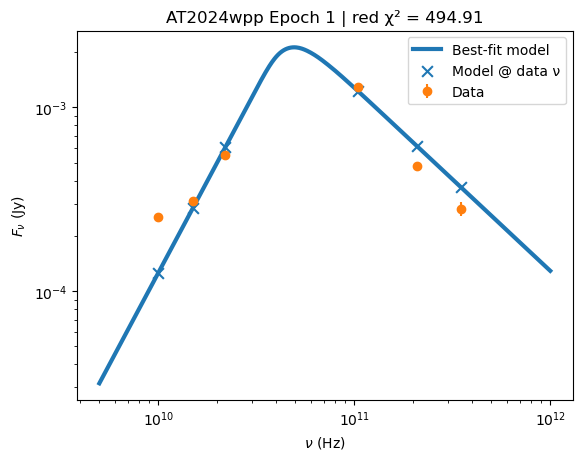

In [22]:
out1 = fit_and_plot_epoch_chi2(epoch=1, theta0=theta0, bounds=bounds, 
                               therm_el=True, pl_el=True)
plt.show()


Epoch 2
----------------
Best-fit theta = [a, log10R, BG, log10n0, log10eps_B]
[ 4.         16.21451765  0.97430737  2.14249077 -1.28713625]
chi2 = 84.8, ndof = 2, red chi2 = 42.4


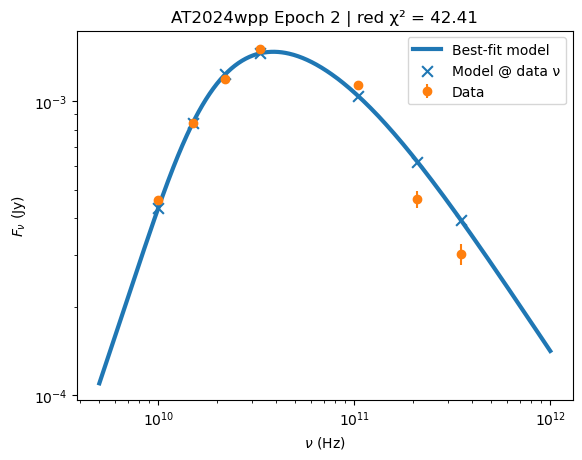

In [23]:
out2 = fit_and_plot_epoch_chi2(epoch=2, theta0=theta0, bounds=bounds, 
                               therm_el=True, pl_el=True)
plt.show()


Epoch 3
----------------
Best-fit theta = [a, log10R, BG, log10n0, log10eps_B]
[ 3.77126574 16.7214483   0.42454335  2.89074359 -1.27091623]
chi2 = 7.7, ndof = 2, red chi2 = 3.85


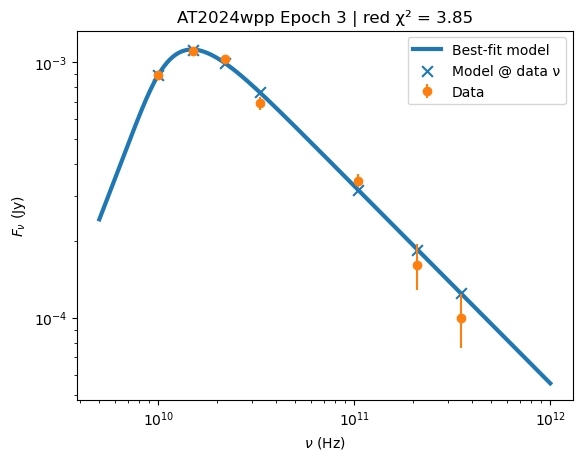

In [25]:
out3 = fit_and_plot_epoch_chi2(epoch=3, theta0=theta0, bounds=bounds, 
                               therm_el=True, pl_el=True)
plt.show()


Epoch 4
----------------
Best-fit theta = [a, log10R, BG, log10n0, log10eps_B]
[ 4.         17.1383144   0.13383374  4.64517128 -0.3       ]
chi2 = 0.821, ndof = 0, red chi2 = nan


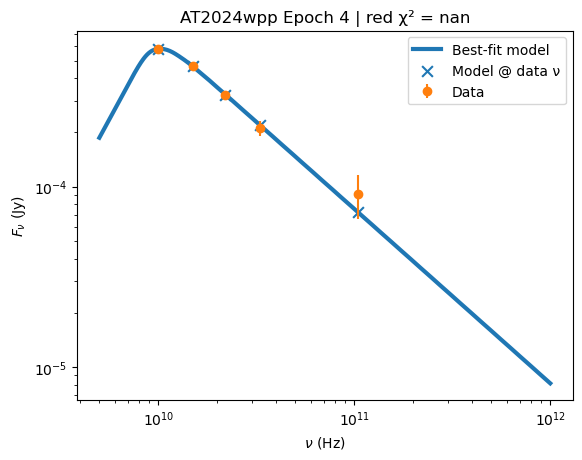

In [26]:
out4 = fit_and_plot_epoch_chi2(epoch=4, theta0=theta0, bounds=bounds, 
                               therm_el=True, pl_el=True)
plt.show()


Epoch 5
----------------
Best-fit theta = [a, log10R, BG, log10n0, log10eps_B]
[ 4.         16.83959155  0.26126726  2.82308879 -0.58022169]
chi2 = 4.2, ndof = -1, red chi2 = nan


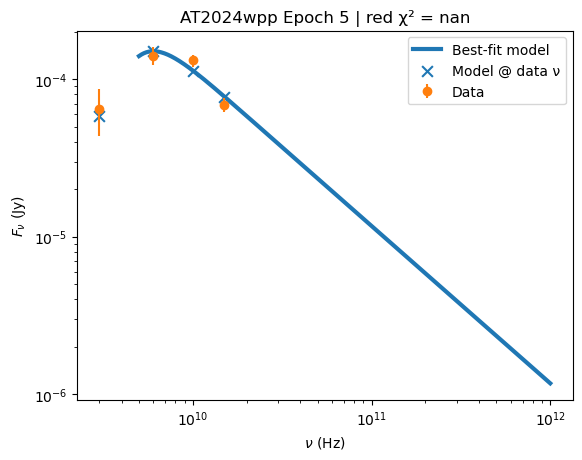

In [27]:
out5 = fit_and_plot_epoch_chi2(epoch=5, theta0=theta0, bounds=bounds, 
                               therm_el=True, pl_el=True)
plt.show()

In [30]:
# Fitting each epoch's SED with different starting points 
# just to see how varied the bestfits can get

def sample_thetas_uniform(n, lb, ub, seed=None):
    rng = np.random.default_rng(seed)
    u = rng.random((n, len(lb)))
    return lb + u * (ub - lb)

def multistart_fit_epoch(epoch, n_success, bounds, therm_el=True, pl_el=False, max_nfev=1000):
    """
    Collect n_success successful least_squares results or stop at max_attempts.
    """
    lb = np.asarray(bounds[0], float)
    ub = np.asarray(bounds[1], float)

    source_params, d_L, freq, flux, fluxErr = AT2024wpp(epoch)
    max_attempts = 10 * n_success

    thetas0 = np.full((n_success, len(lb)), np.nan, dtype=float)
    thetas_hat = np.full_like(thetas0, np.nan)
    chi2 = np.full((n_success,), np.nan, dtype=float)
    success = np.zeros((n_success,), dtype=bool)
    nfev = np.zeros((n_success,), dtype=int)
    messages = [""] * n_success

    got = 0
    attempts = 0
    rng = np.random.default_rng(0) # just chose 0 for seed
    while got < n_success and attempts < max_attempts:
        attempts += 1

        x0 = sample_thetas_uniform(1, lb, ub, seed=rng.integers(0, 2**32 - 1))[0]  # shape (5,)

        try:
            res = least_squares(
                residuals, x0=x0, bounds=(lb, ub),
                args=(source_params, d_L, freq, flux, fluxErr, therm_el, pl_el),
                method="trf", max_nfev=max_nfev
            )

            # Finish run and confirm that there's no nans in the fitting
            if res.success and np.all(np.isfinite(res.x)) and np.isfinite(res.cost):
                thetas0[got] = x0
                thetas_hat[got] = res.x
                chi2[got] = float(np.sum(res.fun**2))
                success[got] = True
                nfev[got] = int(res.nfev)
                messages[got] = str(res.message)
                got += 1

                if (got % max(1, n_success // 10) == 0):
                    print(f"Epoch {epoch}: got {got}/{n_success} successes (attempts={attempts})")

        except Exception as e:
            print(f"Epoch {epoch}: attempt {attempts}") # don't crash

    if got < n_success:
        print(f"Warning: epoch {epoch} only got {got}/{n_success} successful fits after {attempts} attempts.")
        # trim arrays to what we actually got
        thetas0 = thetas0[:got]
        thetas_hat = thetas_hat[:got]
        chi2 = chi2[:got]
        success = success[:got]
        nfev = nfev[:got]
        messages = messages[:got]

    ndof = len(freq) - len(lb)
    if ndof > 0: red_chi2 = chi2 / ndof 
    else: red_chi2 = np.full_like(chi2, np.nan)

    return dict(
        epoch=epoch,
        source_params=source_params,
        d_L=d_L,
        freq=freq,
        flux=flux,
        fluxErr=fluxErr,
        theta0s=thetas0,
        thetas=thetas_hat,
        chi2=chi2,
        red_chi2=red_chi2,
        ndof=ndof,
        success=success,
        nfev=nfev,
        messages=messages,
        bounds=(lb, ub),
        therm_el=therm_el,
        pl_el=pl_el,
    )

def select_solutions(out, delta_chi2=10):
    """
    Select 'good' solutions by delta chi-square or by top fraction.
    - delta_chi2: keep solutions with chi2 <= chi2_min + delta_chi2
    """
    chi2 = out["chi2"]
    ok = np.isfinite(chi2)

    ok &= out["success"]

    chi2_min = np.nanmin(chi2[ok])

    ok &= (chi2 <= chi2_min + float(delta_chi2))

    return np.where(ok)[0]
    
def plot_param_hists(out, idx_keep):
    labels = ["a", "log10R", "BG", "log10n0", "log10eps_B"]
    thetas = out["thetas"][idx_keep]
    chi2 = out["chi2"][idx_keep]

    N = len(thetas)
    bins = min(30, max(10, int(np.sqrt(max(N, 1)))))

    fig, axes = plt.subplots(1, thetas.shape[1], figsize=(4*thetas.shape[1], 3))
    if thetas.shape[1] == 1:
        axes = [axes]

    for j in range(thetas.shape[1]):
        axes[j].hist(thetas[:, j], bins=bins)
        axes[j].set_xlabel(labels[j])
        axes[j].set_ylabel("count")

    fig.suptitle(
        f"Epoch {out['epoch']} | kept {len(idx_keep)} sols | "
        f"chi2_min={np.nanmin(chi2):.2g} (ndof={out['ndof']})",
        y=1.05
    )
    fig.tight_layout()
    return fig, axes

def theta_to_physical(theta):
    """Map [a, log10R, BG, log10n0, log10epsB] -> physical values."""
    a, log10R, BG, log10n0, log10epsB = theta
    return dict(
        a=float(a),
        R=10.0**float(log10R),
        BG=float(BG),
        n0=10.0**float(log10n0),
        eps_B=10.0**float(log10epsB),
    )

def plot_overlay_curves(out, idx_keep):
    source_params = out["source_params"]
    d_L = out["d_L"]
    freq, flux, fluxErr = out["freq"], out["flux"], out["fluxErr"]
    therm_el, pl_el = out["therm_el"], out["pl_el"]

    nu_grid = np.logspace(np.log10(nu_low), np.log10(nu_high), int(nu_res))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(freq, flux, yerr=fluxErr, fmt="o", label="Data")

    for i in idx_keep:
        theta = out["thetas"][i]
        phys = theta_to_physical(theta)
        params = {**source_params, **phys}

        Lnu = compute_Lnu_R(nu_grid, params, therm_el, pl_el)
        Fnu = Lnu / (4*np.pi*d_L**2) / C.Jy
        ax.plot(nu_grid, Fnu, lw=1, alpha=0.3)

    # best curve thick
    chi2 = out["chi2"]
    best_i = idx_keep[np.argmin(chi2[idx_keep])]
    best_theta = out["thetas"][best_i]
    best_phys = theta_to_physical(best_theta)
    params_best = {**source_params, **best_phys}
    
    Lnu_best = compute_Lnu_R(nu_grid, params_best, therm_el, pl_el)
    Fnu_best = Lnu_best / (4*np.pi*d_L**2) / C.Jy
    ax.plot(nu_grid, Fnu_best, lw=3, label="Best (min chi2)")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\nu$ (Hz)"); ax.set_ylabel(r"$F_\nu$ (Jy)")
    ax.set_title(f"Epoch {out['epoch']} | overlay {len(idx_keep)} solutions")
    ax.legend(); fig.tight_layout()
    return fig, ax

def summarize_solutions(out, idx_keep):
    if len(idx_keep) == 0: print("No solutions selected."); return

    chi2 = out["chi2"][idx_keep]
    thetas = out["thetas"][idx_keep]
    best = idx_keep[np.argmin(chi2)]
    print(f"Selected {len(idx_keep)} solutions")
    print(f"chi2 min/med/max = {np.min(chi2):.3g} / {np.median(chi2):.3g} / {np.max(chi2):.3g}")
    print("Best theta:", out["thetas"][best])
    print("Best physical:", theta_to_physical(out["thetas"][best]))


Epoch 1: got 10/100 successes (attempts=10)
Epoch 1: got 20/100 successes (attempts=20)
Epoch 1: got 30/100 successes (attempts=30)
Epoch 1: got 40/100 successes (attempts=40)
Epoch 1: got 50/100 successes (attempts=50)
Epoch 1: got 60/100 successes (attempts=60)
Epoch 1: got 70/100 successes (attempts=70)
Epoch 1: got 80/100 successes (attempts=80)
Epoch 1: got 90/100 successes (attempts=90)
Epoch 1: got 100/100 successes (attempts=100)
Selected 1 solutions
chi2 min/med/max = 54.8 / 54.8 / 54.8
Best theta: [ 1.68582026 18.          0.22821694  4.79432135 -5.        ]
Best physical: {'a': 1.6858202580323318, 'R': 9.999999999999918e+17, 'BG': 0.22821694118673597, 'n0': 62276.09128333817, 'eps_B': 1.0000000000046281e-05}


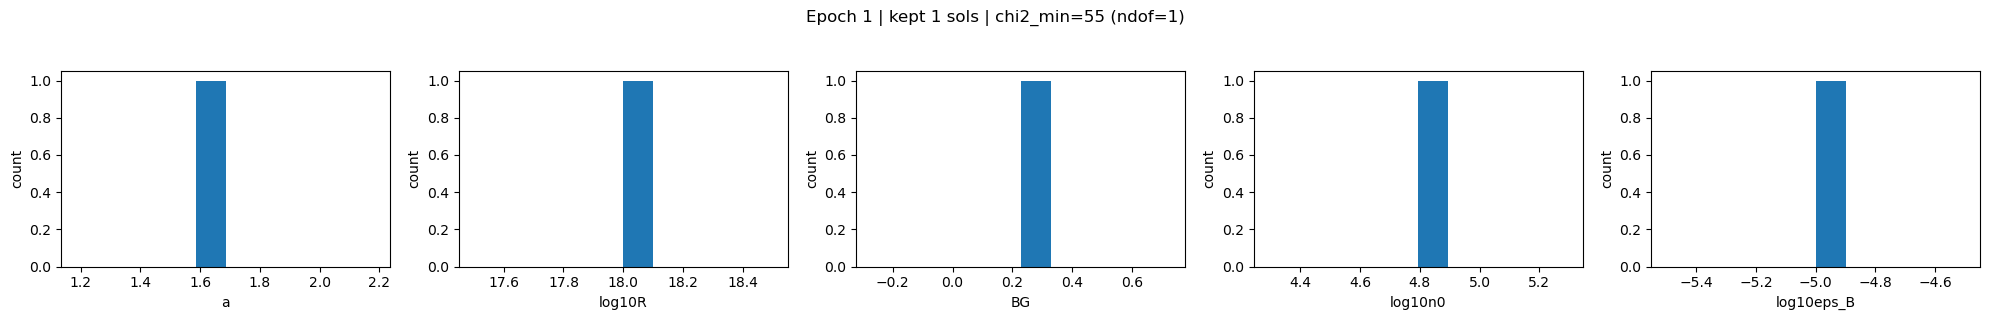

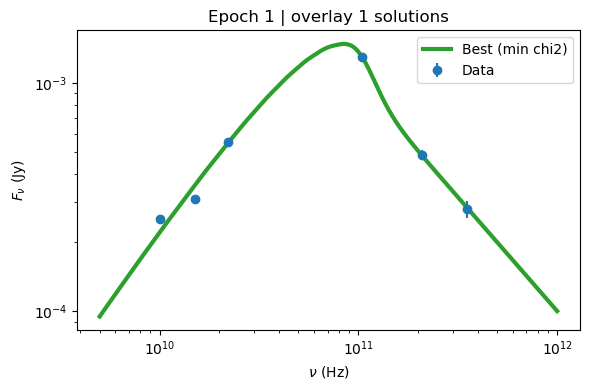

In [31]:
out1 = multistart_fit_epoch(epoch=1, n_success=100, bounds=bounds, 
                            therm_el=True, pl_el=True, max_nfev=1000)

idx_keep1 = select_solutions(out1, delta_chi2=10.0)

summarize_solutions(out1, idx_keep1)

plot_param_hists(out1, idx_keep1)
plot_overlay_curves(out1, idx_keep1)
plt.show()

Epoch 2: got 10/100 successes (attempts=10)
Epoch 2: got 20/100 successes (attempts=20)
Epoch 2: got 30/100 successes (attempts=30)
Epoch 2: got 40/100 successes (attempts=40)
Epoch 2: got 50/100 successes (attempts=50)
Epoch 2: got 60/100 successes (attempts=60)
Epoch 2: got 70/100 successes (attempts=70)
Epoch 2: got 80/100 successes (attempts=80)
Epoch 2: got 90/100 successes (attempts=90)
Epoch 2: got 100/100 successes (attempts=100)
Selected 25 solutions
chi2 min/med/max = 27.5 / 27.5 / 28.2
Best theta: [ 0.89532228 16.38260107  1.78098145  2.10318501 -3.95912881]
Best physical: {'a': 0.8953222773485411, 'R': 2.41324307283538e+16, 'BG': 1.7809814470683838, 'n0': 126.8191997408642, 'eps_B': 0.00010986799323914539}


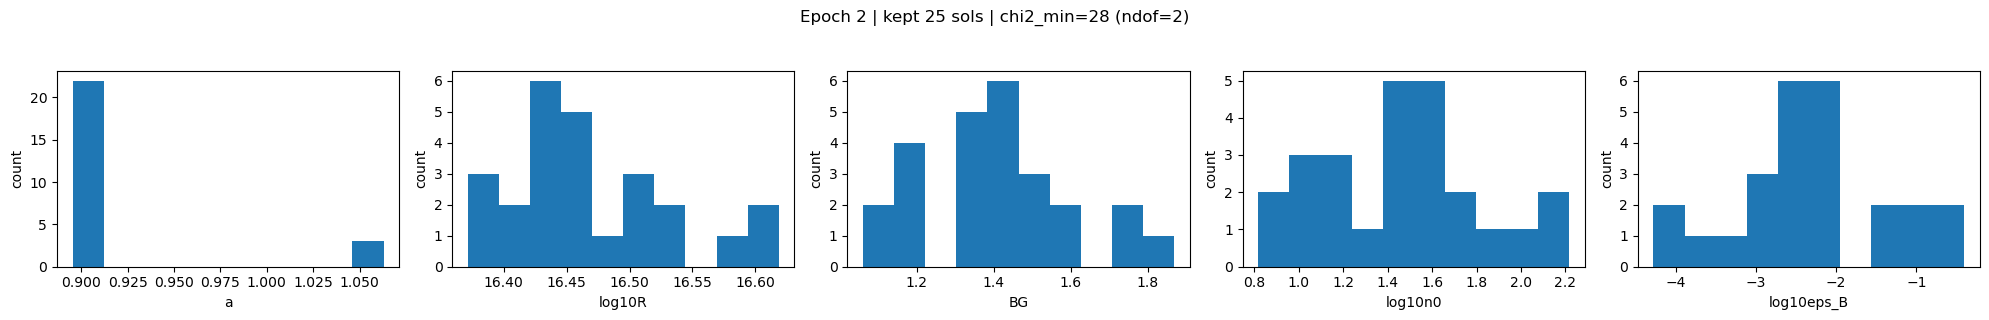

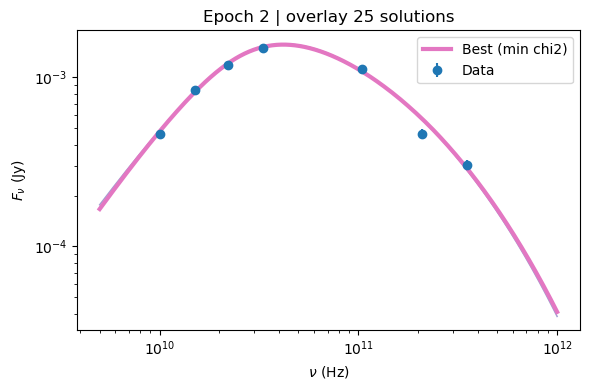

In [32]:
out2 = multistart_fit_epoch(epoch=2, n_success=100, bounds=bounds, 
                            therm_el=True, pl_el=True, max_nfev=1000)

idx_keep2 = select_solutions(out2, delta_chi2=10.0)

summarize_solutions(out2, idx_keep2)

plot_param_hists(out2, idx_keep2)
plot_overlay_curves(out2, idx_keep2)
plt.show()

Epoch 3: got 10/100 successes (attempts=10)
Epoch 3: got 20/100 successes (attempts=20)
Epoch 3: got 30/100 successes (attempts=30)
Epoch 3: got 40/100 successes (attempts=40)
Epoch 3: got 50/100 successes (attempts=50)
Epoch 3: got 60/100 successes (attempts=60)
Epoch 3: got 70/100 successes (attempts=70)
Epoch 3: got 80/100 successes (attempts=80)
Epoch 3: got 90/100 successes (attempts=90)
Epoch 3: got 100/100 successes (attempts=100)
Selected 60 solutions
chi2 min/med/max = 7.7 / 7.7 / 7.7
Best theta: [ 3.771266   16.5132252   0.6992478   4.2250076  -4.79905442]
Best physical: {'a': 3.7712660030890364, 'R': 3.2600570177567364e+16, 'BG': 0.6992478000435063, 'n0': 16788.33378726446, 'eps_B': 1.588347705865895e-05}


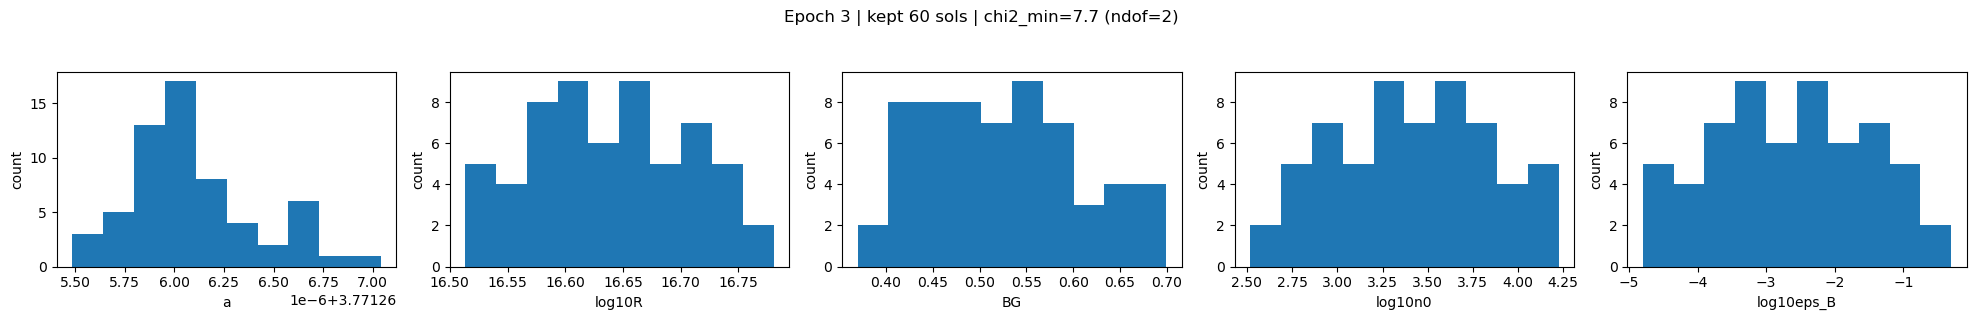

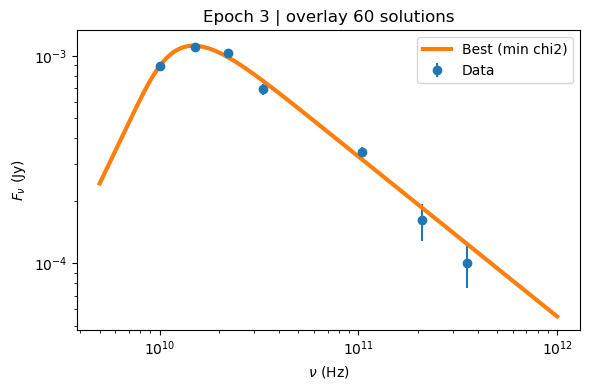

In [33]:
out3 = multistart_fit_epoch(epoch=3, n_success=100, bounds=bounds, 
                            therm_el=True, pl_el=True, max_nfev=1000)

idx_keep3 = select_solutions(out3, delta_chi2=10.0)

summarize_solutions(out3, idx_keep3)

plot_param_hists(out3, idx_keep3)
plot_overlay_curves(out3, idx_keep3)
plt.show()